In [56]:
import json
from datetime import datetime, date, time
import re
import numpy as np
import matplotlib.pyplot as plt

In [57]:
# Define constants

path_ids = "./data/railcross.id_to_names.json"
path_online = "./data/railcross.railcross_online-2019-05-01_2019-10-01.json"
path_open = "./data/railcross.railcross_statuses-2019-05-01_2019-10-01.json"

period_start = datetime(2019,5,1,0,0,0)
period_end = datetime(2019,10,1,0,0,0)

In [58]:
print("Loading data...")

Loading data...


In [59]:
# Read ids and names

jsondata = ""
with open(path_ids) as data_in:
    for line in data_in:
        # convert the TenGen JSON to Strict JSON
        # https://issue.life/questions/52672598
        jsondata += re.sub(r'\:\s*\S+\s*\(\s*(\S+)\s*\)',
                      r':\1',
                      line)
        
list_id_to_name = json.loads(jsondata)
#print(dict_id_to_name[0])

nr_of_crossings = len(list_id_to_name)
       
def id_to_index(id):
    for i in range(nr_of_crossings):
        id_list = list_id_to_name[i]['_id']
        if id==id_list:
            return i
    return None
    
def index_to_name(index):
    return list_id_to_name[index]['name']    
    
#print(id_to_index("5bee7f1305560b3433572742"))  
#print(index_to_name(0))  

print("Number of crossings: ", nr_of_crossings)
for i in range(0, nr_of_crossings):
    print("\t", i, ": ", index_to_name(i), "\t", list_id_to_name[i]['_id']) 

Number of crossings:  5
	 0 :  vushneve 	 5bee7f1305560b3433572742
	 1 :  boyarka 	 5c1b3e3d184dd73693eb13a4
	 2 :  tarasivka 	 5c1b3e3f184dd73693eb13a5
	 3 :  bucha 	 5cb724b1e40e390194936beb
	 4 :  irpin 	 5d54e0f33afb8f7a6fbc0904


In [60]:
# Read online statuses

jsondata = ""
with open(path_online) as data_in:
    for line in data_in:
        # convert the TenGen JSON to Strict JSON
        # https://issue.life/questions/52672598
        jsondata += re.sub(r'\:\s*\S+\s*\(\s*(\S+)\s*\)',
                      r':\1',
                      line)
        
list_online = json.loads(jsondata)
#print(list_online[0])

nr_of_online_records = len(list_online)
print("Online status records: ", nr_of_online_records)


Online status records:  7994


In [61]:
# Read open statuses

jsondata = ""
with open(path_open) as data_in:
    for line in data_in:
        # convert the TenGen JSON to Strict JSON
        # https://issue.life/questions/52672598
        jsondata += re.sub(r'\:\s*\S+\s*\(\s*(\S+)\s*\)',
                      r':\1',
                      line)
        
dict_open = json.loads(jsondata)
#print(dict_open[0])

nr_of_open_records = len(dict_open)
print("Open status records: ", nr_of_open_records)

Open status records:  129170


In [62]:
# Create input NumPy array

delta_period = period_end - period_start
period_minutes = int(delta_period.total_seconds() / 60)
print("Period: ", period_minutes, " minutes (", delta_period.days, "days )")

minute_array = np.zeros((period_minutes, nr_of_crossings), dtype=int)
print("Input array shape: ", np.shape(minute_array))


Period:  220320  minutes ( 153 days )
Input array shape:  (220320, 5)


In [63]:
# Fill the input NumPy array with online status

online_statuses_start_mins = [0] * nr_of_crossings # Set start times to zero

for r in range(nr_of_online_records):  
    
    # Get index, time and status
    
    online_record = list_online[r]
    #print(online_record)
    crossing_index = id_to_index(online_record['railcross'])
    #print(crossing_index)
    
    crossing_time = datetime.strptime(online_record["added"], '%Y-%m-%dT%H:%M:%S.%f%z')
    crossing_time = crossing_time.replace(tzinfo=None)
    #print(crossing_time)
    #print(period_start)
    crossing_relative_time_mins = int((crossing_time - period_start).total_seconds()/60)
    #print(crossing_relative_time_mins)
    crossing_online_status = online_record["online_status"]
    #print(crossing_online_status)
    
    
    if crossing_online_status == True: # Online
        online_statuses_start_mins[crossing_index] = crossing_relative_time_mins # Fix start time
        
    if crossing_online_status == False: # Offline
        #print(crossing_relative_time_mins)
        if online_statuses_start_mins[crossing_index] != -1: # Just in case there are double statuses
            for t in range(online_statuses_start_mins[crossing_index], crossing_relative_time_mins):
                minute_array[t][crossing_index] = 1 # Set the online status
            online_statuses_start_mins[crossing_index] = -1
        
# Finish        
#print(online_statuses_start_mins, period_minutes)
for c in range(nr_of_crossings):  
    if online_statuses_start_mins[c] != -1:
        for t in range(online_statuses_start_mins[c], period_minutes):
            minute_array[t][c] = 1 # Set the online status
        
 
#print(minute_array)    
    

In [64]:
# Fill the input NumPy array with open status

open_statuses_start_mins = [0] * nr_of_crossings # Set start times to zero
prev_mult = [1] * nr_of_crossings # Prev states are 'open'

for r in range(nr_of_open_records):  
    
    # Get index, time and status
    
    open_record = dict_open[r]
    #print(open_record)
    crossing_index = id_to_index(open_record['railcross']['$oid'])
    #print(crossing_index)
    
    crossing_time = datetime.strptime(open_record["added"]['$date'], '%Y-%m-%dT%H:%M:%S.%f%z')
    crossing_time = crossing_time.replace(tzinfo=None)
    #print(crossing_time)
    #print(period_start)
    crossing_relative_time_mins = int((crossing_time - period_start).total_seconds()/60)
    #print(crossing_relative_time_mins)
    crossing_open_status = open_record["open_status"]
    #print(crossing_open_status)
    

    mult = 0
    if crossing_open_status==True: # Now 'open'
        mult = -1 
    if crossing_open_status==False: # Now 'close'
        mult = 1
            
    for t in range(open_statuses_start_mins[crossing_index], crossing_relative_time_mins):
        minute_array[t][crossing_index] *= mult
            
    prev_mult[crossing_index] = -mult
    open_statuses_start_mins[crossing_index] = crossing_relative_time_mins
    
    
#    if crossing_open_status == True: # Open
#        for t in range(open_statuses_start_mins[crossing_index], crossing_relative_time_mins):
#            minute_array[t][crossing_index] *= -1 # Set the online status to 'closed'
#        open_statuses_start_mins[crossing_index] = crossing_relative_time_mins # Fix start time
        
#    if crossing_open_status == False: # Closed
        #print(crossing_relative_time_mins)
#        if open_statuses_start_mins[crossing_index] != -1: # Just in case there are double statuses
#        for t in range(open_statuses_start_mins[crossing_index], crossing_relative_time_mins):
#            minute_array[t][crossing_index] *= 1 # Set the online status
#        open_statuses_start_mins[crossing_index] = crossing_relative_time_mins # Fix start time
#            open_statuses_start_mins[crossing_index] = -1
        
# Finish        
#print(open_statuses_start_mins, period_minutes)
for c in range(nr_of_crossings):  
    for t in range(open_statuses_start_mins[c], period_minutes):
        minute_array[t][c] *= prev_mult[c] # Set the open status
        
 
#print(minute_array)


In [80]:
# Print statistics

print("Statistics:")
            
for c in range(nr_of_crossings):
    
    offline_mins = 0
    open_mins = 0
    closed_mins = 0
    
    for t in range(period_minutes):
        if minute_array[t][c] == 1:
            open_mins += 1
        if minute_array[t][c] == -1:
            closed_mins += 1
        if minute_array[t][c] == 0:
            offline_mins += 1

    
    print(c, 
          ": open:", round(open_mins/period_minutes*100), 
          "%,\tclosed: ", round(closed_mins/period_minutes*100),
          "%,\toffline: ", round(offline_mins/period_minutes*100),
          "%\t\t", index_to_name(c) )

Statistics:
0 : open: 43 %,	closed:  43 %,	offline:  15 %		 vushneve
1 : open: 33 %,	closed:  12 %,	offline:  55 %		 boyarka
2 : open: 31 %,	closed:  9 %,	offline:  59 %		 tarasivka
3 : open: 70 %,	closed:  30 %,	offline:  1 %		 bucha
4 : open: 11 %,	closed:  3 %,	offline:  86 %		 irpin


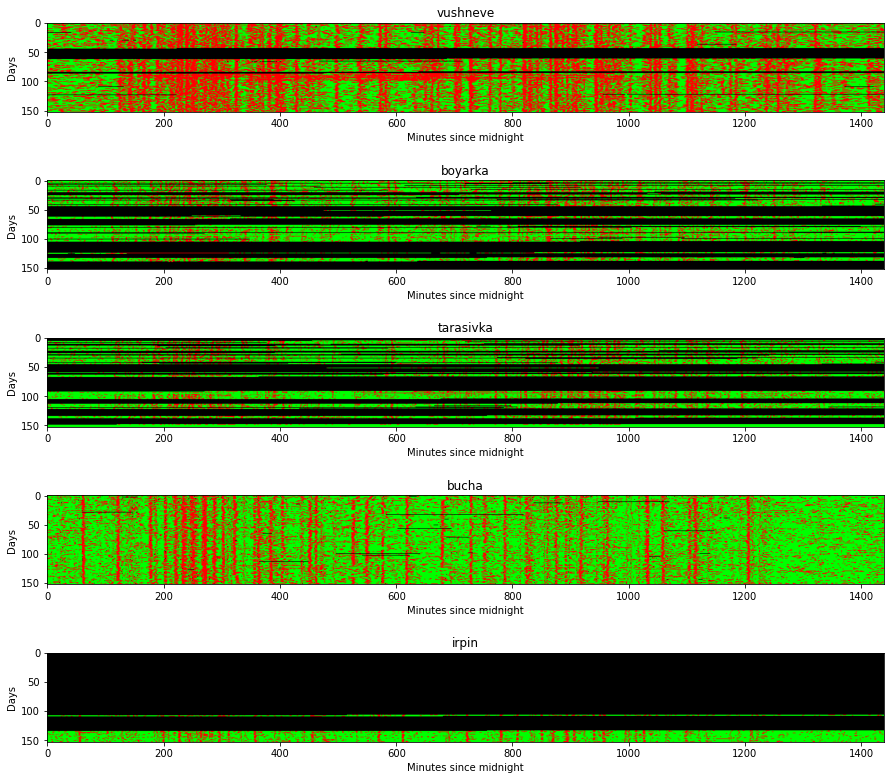

In [81]:
# Show images

w = 1440
h = period_minutes // w

fig=plt.figure(figsize=(15, 14))
data = np.zeros((h, w, 3), dtype=np.uint8)

for c in range(nr_of_crossings): #(nr_of_crossings):


    for t in range(period_minutes):
        x = t % w
        y = t // w
    
        data[y][x][0] = 0
        data[y][x][1] = 0
        data[y][x][2] = 0
        
        if minute_array[t][c] == 1:
            data[y][x][1] = 255     
        elif minute_array[t][c] == -1:
            data[y][x][0] = 255         
        
    fig.add_subplot(nr_of_crossings, 1, c+1)
    plt.title(index_to_name(c))
    plt.ylabel("Days")
    plt.xlabel("Minutes since midnight")
    plt.imshow(data)   
    #Image.fromarray(data, 'RGB').show()
plt.show()        